# Forced Kernel 

1. Synthetic `Havlicek` dataset with a specific quantum circuit
2. Kernel made with that quantum circuit
3. Train SVM
    - Classical kernel is expected to fail
    - Quantum kernel has to have 1.0 accuracy

In [ ]:
import matplotlib.pyplot as plt
import pennylane as qml
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

from src.data.synthetic import *
from src.utils.visuals import *
from src.data.preprocessing import preprocess_synthetic
from src.optimization.classical_base import classical_benchmark

## 0. Classical Benchmarking

In [26]:
candidate, _ = find_hard_generating_candidate(n_candidates=10)
deltas = np.linspace(0.1, 0.3, 10)
accuracies_modhav = []
for delta in deltas:
    accs = []
    for seed in range(9):
        X, y = ModHav_synthetic_dataset(seed=seed, delta=delta, enc_candidate=candidate)
        X_train, X_test, y_train, y_test = preprocess_synthetic(X, y, N_QUBITS)
        results = classical_benchmark(X_train, y_train, X_test, y_test)
        accs.append(results['accuracy'])
    accuracies_modhav.append(np.mean(accs))

Best of 10: g = 55.9378

Caching the list of root modules, please wait!
(This will only be done once - type '%rehashx' to reset cache!)



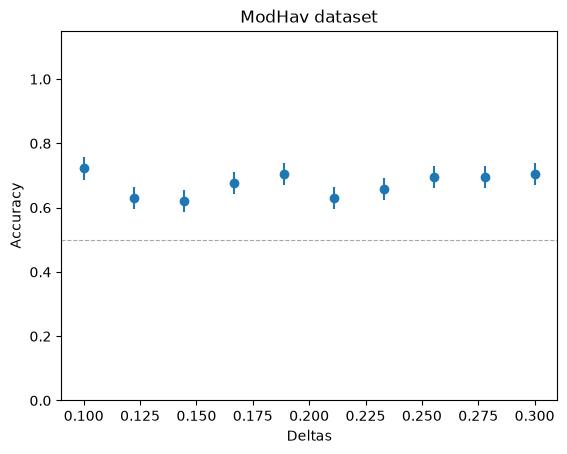

In [8]:
plt.errorbar(deltas, accuracies_modhav, yerr=np.std(accuracies_modhav), fmt='o')
plt.ylabel('Accuracy')
plt.xlabel('Deltas')
plt.title('ModHav dataset')
plt.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.7, label='Random guess')
plt.ylim(0, 1.15)
plt.show()

In [3]:
deltas = np.linspace(0.1, 0.6, 10)
accuracies_classic = []
for delta in deltas:
    accs = []
    for seed in range(9):
        X, y = Havlicek_synthetic_dataset(seed=seed, delta=delta)
        X_train, X_test, y_train, y_test = preprocess_synthetic(X, y, N_QUBITS)
        results = classical_benchmark(X_train, y_train, X_test, y_test)
        accs.append(results['accuracy'])
    accuracies_classic.append(np.mean(accs))

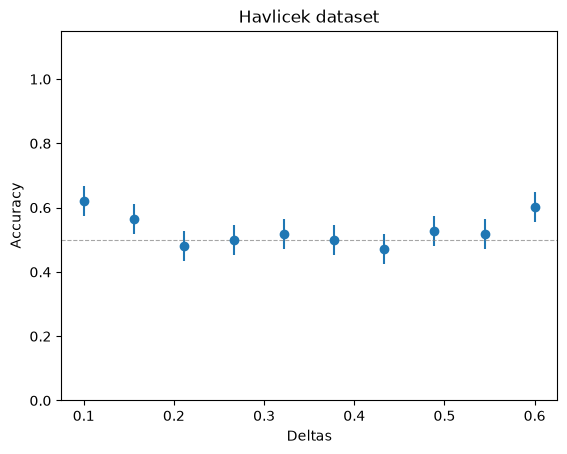

In [4]:
plt.errorbar(deltas, accuracies_classic, yerr=np.std(accuracies_classic), fmt='o')
plt.ylabel('Accuracy')
plt.xlabel('Deltas')
plt.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.7, label='Random guess')
plt.title('Havlicek dataset')
plt.ylim(0, 1.15)
plt.show()

## 1. Havlicek dataset

Objective: Find a kernel that has 1.0 accuracy vs a classical with roughly 0.5 accuracy

In [6]:
n_qubits = N_QUBITS
def quantum_kernel_matrix_havlicek(X1, X2 = None):

    def feature_map(x):
        """Encode data in quantum state. Havlicek et al."""
        # superposition
        for i in range(n_qubits):
            qml.Hadamard(wires=i)
            qml.RZ(2 * x[i], wires=i)

        # encoding information
        for i in range(n_qubits):
            for j in range(i+1, n_qubits):
                qml.CNOT(wires=[i, j])
                qml.RZ(2 * (np.pi - x[i]) * (np.pi - x[j]), wires=j)
                qml.CNOT(wires=[i, j])

    dev = qml.device("default.qubit", wires=n_qubits)
    @qml.qnode(dev)
    def quantum_kernel_circuit(x1, x2):
        feature_map(x1)
        qml.adjoint(feature_map)(x2) # pyright: ignore[reportCallIssue]
        return qml.probs(wires=range(n_qubits))

    def quantum_kernel(x1, x2):
        return float(quantum_kernel_circuit(x1, x2)[0])

    if X2 is None:
        N = len(X1)
        K_quantum = np.zeros((N, N))

        for i in range(N):
            for j in range(i, N):
                value = quantum_kernel(X1[i], X1[j])
                K_quantum [i,j] = value
                K_quantum [j,i] = value
    else:
        # former 'quantum_kernel_matrix_cross()'
        N1, N2 = len(X1), len(X2)
        K_quantum = np.zeros((N1, N2))
        for i in range(N1):
            for j in range(N2):
                K_quantum[i, j] = quantum_kernel(X1[i], X2[j])
    return K_quantum
        

In [ ]:
## FORCED KERNEL
deltas = np.linspace(0.1, 0.6, 10)
accuracies_q = []
for delta in deltas:
    accs_q = []
    for seed in range(9):
        X, y = Havlicek_synthetic_dataset(delta=delta, seed=seed)
        X_train, X_test, y_train, y_test = preprocess_synthetic(X, y, N_QUBITS)

        # call quantum kernel
        K_train = quantum_kernel_matrix_havlicek(X_train)
        K_test = quantum_kernel_matrix_havlicek(X_test, X_train)

        # grid search over C
        c_range = {'C': [0.1, 1, 10, 100, 1000]}
        grid = GridSearchCV(
            SVC(kernel='precomputed', class_weight='balanced'), c_range, cv=5,
            scoring='balanced_accuracy', refit=True,
        )
        grid.fit(K_train, y_train)

        # prediction
        y_pred = grid.best_estimator_.predict(K_test)
        accuracy = accuracy_score(y_test, y_pred)
        accs_q.append(accuracy)
    accuracies_q.append(np.mean(accs_q))


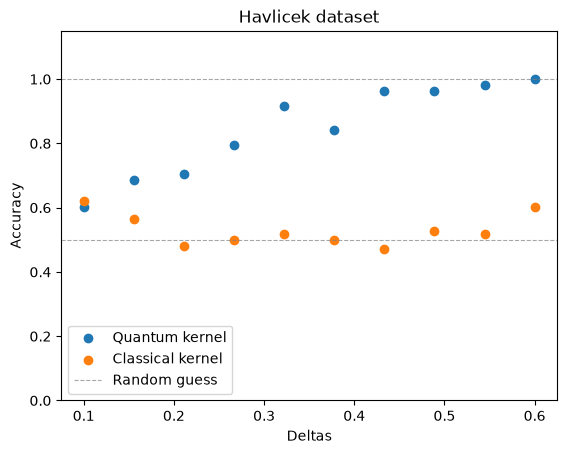

In [ ]:
plt.title('Havlicek dataset')
plt.ylabel('Accuracy')
plt.xlabel('Deltas')
plt.scatter(deltas, accuracies_q, label='Quantum kernel', color='tab:blue')
plt.scatter(deltas, accuracies_classic, label='Classical kernel', color='tab:orange')
for n in range(len(deltas)):
    plt.plot(deltas[n], accuracies_q[n], color='tab:blue', alpha=0.5)
    plt.plot(deltas[n], accuracies_classic[n], color='tab:orange', alpha=0.5)
plt.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.7, label='Random guess')
plt.axhline(1, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
plt.legend()
plt.savefig('Havlicek_dataset_accuracy_comparison.png', dpi=300, bbox_inches='tight')
plt.ylim(0, 1.15)
plt.show()

## 2. ModHav dataset

- Figure out why classical has 1.0 accuracy

In [5]:
from config.experiments import ExperimentConfig
from src.data.saving import svm_exists, load_parameter_train
from src.kernel.quantum_kernel import quantum_kernel_matrix_cross
from src.optimization.pipeline import get_candidate, get_svm_results

config = ExperimentConfig(
    name = '',
    optimizer = 'optuna',
    variant = 'kta',
    subset_method = 'none',
    optimizer_kwargs = {'n_trials': 100},
)


deltas = np.linspace(0.1, 0.6, 10)
accuracies_qq = []
for delta in deltas:
    accs_qq = []
    for seed in range(9):
        config.name = f'KernelGap Synthetic v4/dataset 3/optuna kta 100 d {delta} {seed}'
        X, y = Havlicek_synthetic_dataset(seed=seed, delta=delta)
        X_train, X_test, y_train, y_test = preprocess_synthetic(X, y, N_QUBITS)

        trained_candidate, K_train, K_classical, X_sub, y_sub = get_candidate(config, X_train, y_train)
        g_best = load_parameter_train(config.load_from or config.name).get('g_best', float('nan'))

        K_test = None
        if not svm_exists(config.name):
            print("Computing cross-kernel (test × subset)…")
            K_test = quantum_kernel_matrix_cross(X_test, X_sub, trained_candidate)
        results = get_svm_results(config, K_train, y_sub, K_test, y_test)
        accs_qq.append(results['accuracy'])
        
        unique, counts = np.unique(results['y_pred'], return_counts=True)
        print(f"delta= {delta} seed={seed}: acc={results['accuracy']:.3f}, predicted counts={dict(zip(unique, counts))}")
    accuracies_qq.append(np.mean(accs_qq))

Loading cached candidate for 'KernelGap Synthetic v4/dataset 3/optuna kta 100 d 0.1 0'
Loading cached SVM results for 'KernelGap Synthetic v4/dataset 3/optuna kta 100 d 0.1 0'
delta= 0.1 seed=0: acc=0.833, predicted counts={-1: 6, 1: 6}
Loading cached candidate for 'KernelGap Synthetic v4/dataset 3/optuna kta 100 d 0.1 1'
Loading cached SVM results for 'KernelGap Synthetic v4/dataset 3/optuna kta 100 d 0.1 1'
delta= 0.1 seed=1: acc=0.333, predicted counts={-1: 6, 1: 6}
Loading cached candidate for 'KernelGap Synthetic v4/dataset 3/optuna kta 100 d 0.1 2'
Loading cached SVM results for 'KernelGap Synthetic v4/dataset 3/optuna kta 100 d 0.1 2'
delta= 0.1 seed=2: acc=0.667, predicted counts={-1: 6, 1: 6}
Loading cached candidate for 'KernelGap Synthetic v4/dataset 3/optuna kta 100 d 0.1 3'
Loading cached SVM results for 'KernelGap Synthetic v4/dataset 3/optuna kta 100 d 0.1 3'
delta= 0.1 seed=3: acc=0.500, predicted counts={-1: 8, 1: 4}
Loading cached candidate for 'KernelGap Synthetic v4

In [7]:
print(len(accs_qq))

9


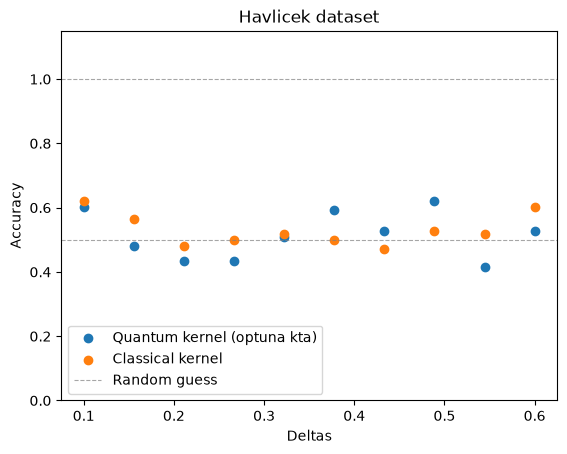

In [14]:
plt.title('Havlicek dataset')
plt.ylabel('Accuracy')
plt.xlabel('Deltas')
plt.scatter(deltas, accuracies_qq, label='Quantum kernel (optuna kta)', color='tab:blue')
plt.scatter(deltas, accuracies_classic, label='Classical kernel', color='tab:orange')
for n in range(len(deltas)):
    plt.plot(deltas[n], accuracies_qq[n], color='tab:blue', alpha=0.5)
    plt.plot(deltas[n], accuracies_classic[n], color='tab:orange', alpha=0.5)
plt.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.7, label='Random guess')
plt.axhline(1, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
plt.legend()
plt.savefig('Havlicek_dataset_accuracy_comparison.png', dpi=300, bbox_inches='tight')
plt.ylim(0, 1.15)
plt.show()

In [11]:
from config.config import *
config = ExperimentConfig(
    name = '',
    optimizer = 'mealpy',
    variant = 'kta',
    subset_method = 'none',
    optimizer_kwargs = {'n_epoch': N_EPOCH, 'n_pop_size': N_POPSIZE, 'n_pm': N_PM},
)


deltas = np.linspace(0.1, 0.6, 10)
accuracies_qqm = []
for delta in [0.1, 0.15555555555555556,0.2111111111111111]:
    accs_qqm = []
    for seed in range(2):
        config.name = f'KernelGap Synthetic v4/dataset 3/mealpy kta 30 e {delta} {seed}'
        X, y = Havlicek_synthetic_dataset(seed=seed, delta=delta)
        X_train, X_test, y_train, y_test = preprocess_synthetic(X, y, N_QUBITS)

        trained_candidate, K_train, K_classical, X_sub, y_sub = get_candidate(config, X_train, y_train)
        g_best = load_parameter_train(config.load_from or config.name).get('g_best', float('nan'))

        K_test = None
        if not svm_exists(config.name):
            print("Computing cross-kernel (test × subset)…")
            K_test = quantum_kernel_matrix_cross(X_test, X_sub, trained_candidate)
        results = get_svm_results(config, K_train, y_sub, K_test, y_test)
        accs_qqm.append(results['accuracy'])
        
        unique, counts = np.unique(results['y_pred'], return_counts=True)
        print(f"delta= {delta} seed={seed}: acc={results['accuracy']:.3f}, predicted counts={dict(zip(unique, counts))}")
    accuracies_qqm.append(np.mean(accs_qqm))

Loading cached candidate for 'KernelGap Synthetic v4/dataset 3/mealpy kta 30 e 0.1 0'
Loading cached SVM results for 'KernelGap Synthetic v4/dataset 3/mealpy kta 30 e 0.1 0'
delta= 0.1 seed=0: acc=0.583, predicted counts={-1: 1, 1: 11}
Loading cached candidate for 'KernelGap Synthetic v4/dataset 3/mealpy kta 30 e 0.1 1'
Loading cached SVM results for 'KernelGap Synthetic v4/dataset 3/mealpy kta 30 e 0.1 1'
delta= 0.1 seed=1: acc=0.500, predicted counts={-1: 10, 1: 2}
Loading cached candidate for 'KernelGap Synthetic v4/dataset 3/mealpy kta 30 e 0.15555555555555556 0'
Loading cached SVM results for 'KernelGap Synthetic v4/dataset 3/mealpy kta 30 e 0.15555555555555556 0'
delta= 0.15555555555555556 seed=0: acc=0.500, predicted counts={-1: 4, 1: 8}
Loading cached candidate for 'KernelGap Synthetic v4/dataset 3/mealpy kta 30 e 0.15555555555555556 1'
Loading cached SVM results for 'KernelGap Synthetic v4/dataset 3/mealpy kta 30 e 0.15555555555555556 1'
delta= 0.15555555555555556 seed=1: acc=

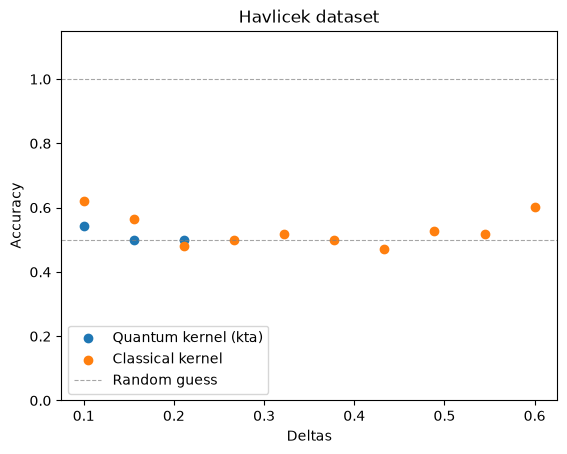

In [13]:
plt.title('Havlicek dataset')
plt.ylabel('Accuracy')
plt.xlabel('Deltas')
plt.scatter([0.1, 0.15555555555555556,0.2111111111111111], accuracies_qqm, label='Quantum kernel (kta)', color='tab:blue')
plt.scatter(deltas, accuracies_classic, label='Classical kernel', color='tab:orange')
for n in range(len(deltas)):
    #plt.plot(deltas[n], accuracies_qqm[n], color='tab:blue', alpha=0.5)
    plt.plot(deltas[n], accuracies_classic[n], color='tab:orange', alpha=0.5)
plt.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.7, label='Random guess')
plt.axhline(1, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
plt.legend()
plt.savefig('Havlicek_dataset_accuracy_comparison.png', dpi=300, bbox_inches='tight')
plt.ylim(0, 1.15)
plt.show()